# MoLA Training Tutorial

Train a model on the simple and small fraction-subtraction dataset.

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# Allows import of modules from src/ in root
%cd ..

/Users/marialentini/Library/CloudStorage/OneDrive-Pearson/Research/Mixture-of-Latent-Archetypes


## Step 1: Download the Fraction-Subtraction Dataset

In [4]:
import pyreadr
import requests
import tempfile

# Helper function to retrieve data from Github
def download_R_file_to_pandas(file_name):

    # Path to datasets in Github CDM repo
    path = "https://raw.githubusercontent.com/cran/CDM/master/data/"
    response = requests.get(path + file_name + ".rda")
    response.raise_for_status()

    # Write .RDA file to temp and load using pyreadr
    with tempfile.NamedTemporaryFile(suffix=".rda", delete=True) as f:
        f.write(response.content)
        f.flush()

        result = pyreadr.read_r(f.name)

    # Fetch pandas dataframe
    df = result[file_name]
    return df

### Step 1a: Download Item-Response Data Matrix
`X`: binary user-item matrix, where a "1" signifies a correct response and a "0" signifies an incorrect response.

In [5]:
# Download the data
df = download_R_file_to_pandas("fraction.subtraction.data")

# Convert to NumPy array
X = df.to_numpy()  

# Print shape and header
print("Item response data shape:", df.shape)
df.head()

Item response data shape: (536, 20)


,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8,Item9,Item10,Item11,Item12,Item13,Item14,Item15,Item16,Item17,Item18,Item19,Item20
0,0,0,0,1,0,0,1,1,0,1,1,1,0,1,1,1,0,1,1,1
1,0,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
2,0,1,1,1,0,1,1,1,0,0,0,0,0,1,1,1,0,0,0,0
3,1,1,1,1,1,1,0,1,0,1,1,1,0,1,0,1,0,1,0,1
4,0,0,0,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0


### Step 1b: Download the Q-matrix

`Q_matrix`: binary item-skill matrix, where a "1" signifies that the item requires the skill, and "0" signifies the opposite.

In [6]:
df = download_R_file_to_pandas("fraction.subtraction.qmatrix")

# Convert to NumPy array
Q_matrix = df.to_numpy()

# Print shape and header
print("Item response data shape:", df.shape)
df.head()

Item response data shape: (20, 8)


,alpha1,alpha2,alpha3,alpha4,alpha5,alpha6,alpha7,alpha8
rownames,,,,,,,,
Item1,0,0,0,1,0,1,1,0
Item2,0,0,0,1,0,0,1,0
Item3,0,0,0,1,0,0,1,0
Item4,0,1,1,0,1,0,1,0
Item5,0,1,0,1,0,0,1,1


## Step 2: Configure and Train the Model

## Stress Test Experiment
Fit a model with way too many components.

In [11]:
from src.mola import MoLA

# Configure model parameters
model_params = {
    'Q_matrix': Q_matrix,
    'n_components': 5,
    'mu_smooth': [2, 2],
    'theta_smooth': [2, 2],
    'pi_smooth': 1,
    'tol': 1e-5,
    'n_iter': 50,
    'use_psuedo_likelihood': False
}

# Instantiate the model
model = MoLA(**model_params)

# Fit the model to the data
model.fit(X)

## Step 3: Visualize Training Results

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

Negative Log-Likelihood: 0.004493157761701844


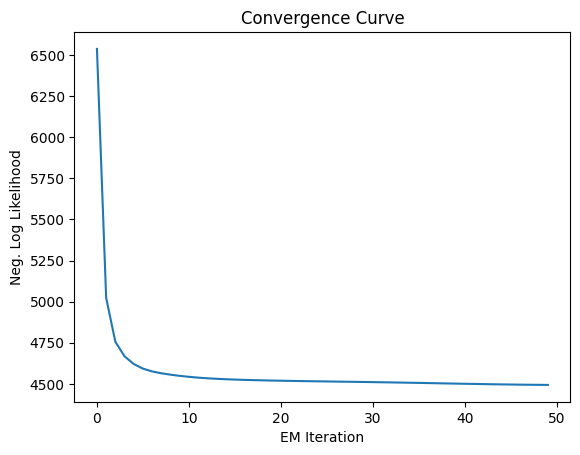

In [9]:
import matplotlib.pyplot as plt
print("Negative Log-Likelihood:", model.nll_trace[-1] * (1e-6))

plt.plot(model.nll_trace)
plt.title('Convergence Curve')
plt.ylabel('Neg. Log Likelihood')
plt.xlabel('EM Iteration')
plt.show()

### Step 3b: Visualize Proficiency Components

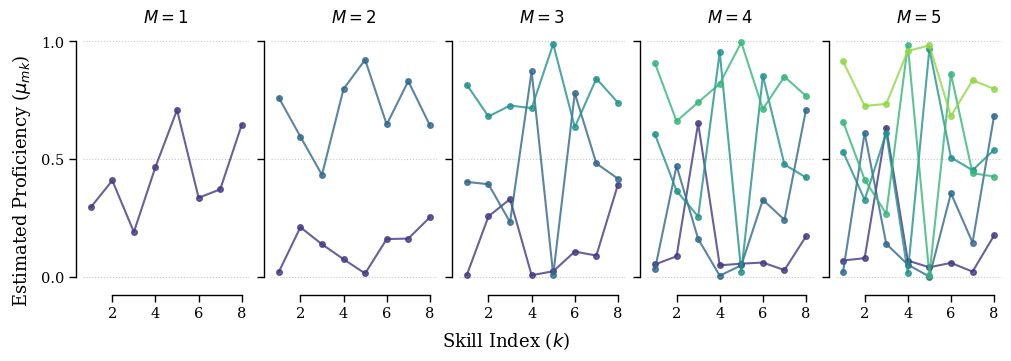

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set plotting context for Academic Paper
sns.set_context("paper", font_scale=1.2)
plt.rcParams['font.family'] = 'serif' # Matches LaTeX default
plt.rcParams['axes.unicode_minus'] = False

component_list = [1, 2, 3, 4, 5]
n = len(component_list)

# Use a professional, high-contrast palette
"rocket"
colors = sns.color_palette("viridis", n_colors=max(component_list))

fig, axes = plt.subplots(1, n, figsize=(10, 3.5), sharey=True, constrained_layout=True)

for i, (ax, n_comp) in enumerate(zip(axes, component_list)):
    # Standardize model setup
    model_params = {
        'Q_matrix': Q_matrix,
        'n_components': n_comp,
        'mu_smooth': [2, 2],
        'theta_smooth': [2, 2],
        'pi_smooth': 1,
        'tol': 1e-5,
        'n_iter': 100, # Increased for stability
        'random_state': 42, # Reproducibility is key for papers
        'use_psuedo_likelihood': False
    }
    
    model_qual = MoLA(**model_params)
    model_qual.fit(X)
    
    # Sort components by mean proficiency to keep colors consistent across plots
    # This makes M=2 and M=3 look like evolutions of each other
    sorted_idx = np.argsort(model_qual.mu.mean(axis=1))
    
    for rank, k in enumerate(sorted_idx):
        ax.plot(range(1, model_qual.mu.shape[1] + 1), model_qual.mu[k, :], 
                color=colors[rank], 
                marker='o', markersize=4, 
                linewidth=1.5, alpha=0.8)
    
    ax.set_title(f'$M={n_comp}$', fontsize=12, fontweight='bold')
    ax.set_xticks([2, 4, 6, 8]) # Show only key indices to prevent crowding
    ax.set_yticks([0.0, 0.5, 1.0])
    ax.grid(axis='y', linestyle=':', alpha=0.7)
    
    # Clean up spines
    sns.despine(ax=ax, offset=5, trim=True)

# Global labels
fig.supxlabel("Skill Index ($k$)", fontsize=13)
fig.supylabel("Estimated Proficiency ($\mu_{mk}$)", fontsize=13)

# Remove the title for the paper version (put it in the LaTeX caption instead)
# fig.suptitle("Latent Proficiency Profiles by Component Count", fontsize=14)

# Save in vector formats for high-quality printing
plt.savefig("./figures/mola_profiles_comparison.pdf", bbox_inches="tight")
plt.show()

In [41]:
labels = [
    "Convert a whole number to a fraction",
    "Separate a whole number from a fraction",
    "Simplify before subtracting",
    "Find a common denominator",
    "Borrow from the whole number part",
    "Column borrow to subtract the second numerator from the first",
    "Subtract numerators",
    "Reduce answers to simplest form"
]

df = pd.DataFrame(model_qual.mu).T
df.index = labels
df

,0,1,2,3,4
Convert a whole number to a fraction,0.914588,0.530878,0.020838,0.068751,0.658566
Separate a whole number from a fraction,0.725726,0.326714,0.611228,0.078748,0.412692
Simplify before subtracting,0.734013,0.611749,0.139562,0.633093,0.267334
Find a common denominator,0.959259,0.015629,0.051273,0.068311,0.984267
Borrow from the whole number part,0.982357,0.967947,0.000198,0.039887,0.005893
Column borrow to subtract the second numerator from the first,0.682730,0.506337,0.354519,0.058701,0.861365
Subtract numerators,0.834552,0.452443,0.144610,0.021551,0.439699
Reduce answers to simplest form,0.797956,0.538842,0.684423,0.175413,0.425397


## Compare Negatively Correlated Archetypes

In [47]:
import pandas as pd
arr = model_qual.mu.mean(axis=1)
ranks = arr.argsort().argsort()
print(arr[(ranks == 1) | (ranks == 2)])


r = pd.DataFrame(model_qual.mu[(ranks == 1) | (ranks == 2), :]).T

# r = pd.DataFrame(model.mu).iloc[[4, 5], :].T
print('corr:', r.corr().iloc[1, 0])

r.index = labels
r.columns = ['Archetype A', 'Archetype B']
r = r.round(3)
print('\n', r.to_latex())
print(r.mean())
r

[0.49381751 0.25083139]
corr: -0.1587900882801723

 \begin{tabular}{lrr}
\toprule
 & Archetype A & Archetype B \\
\midrule
Convert a whole number to a fraction & 0.531000 & 0.021000 \\
Separate a whole number from a fraction & 0.327000 & 0.611000 \\
Simplify before subtracting & 0.612000 & 0.140000 \\
Find a common denominator & 0.016000 & 0.051000 \\
Borrow from the whole number part & 0.968000 & 0.000000 \\
Column borrow to subtract the second numerator from the first & 0.506000 & 0.355000 \\
Subtract numerators & 0.452000 & 0.145000 \\
Reduce answers to simplest form & 0.539000 & 0.684000 \\
\bottomrule
\end{tabular}

Archetype A    0.493875
Archetype B    0.250875
dtype: float64


,Archetype A,Archetype B
Convert a whole number to a fraction,0.531,0.021
Separate a whole number from a fraction,0.327,0.611
Simplify before subtracting,0.612,0.140
Find a common denominator,0.016,0.051
Borrow from the whole number part,0.968,0.000
Column borrow to subtract the second numerator from the first,0.506,0.355
Subtract numerators,0.452,0.145
Reduce answers to simplest form,0.539,0.684


## Comparison Against DINA

In [51]:
import rpy2.robjects as ro


Unable to determine R home: [Errno 2] No such file or directory: 'R'


RuntimeError: Unable to determine R_HOME.

## Tatsuoka's Rule Analysis

                       A1     A2     A3     A4     A5
Regrouping          0.874  0.609  0.211  0.062  0.359
Common Denominator  0.959  0.016  0.051  0.068  0.984
Execution           0.759  0.479  0.250  0.040  0.651
Simplification      0.766  0.575  0.412  0.404  0.346


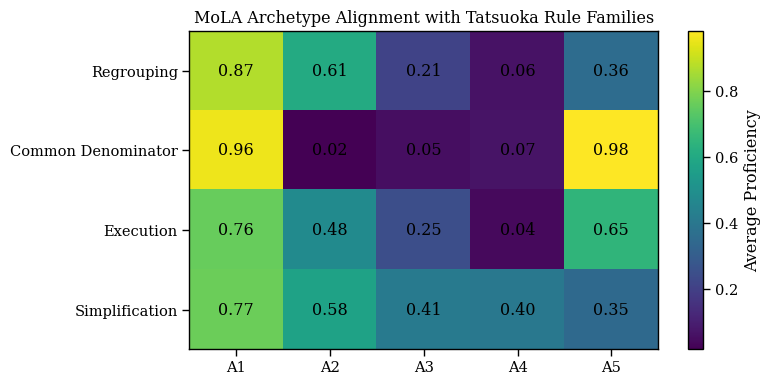

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Tatsuoka-style rule family mapping
# --------------------------------------------------

rule_families = {
    "Regrouping": [
        "Convert a whole number to a fraction",
        "Separate a whole number from a fraction",
        "Borrow from the whole number part",
    ],
    "Common Denominator": [
        "Find a common denominator",
    ],
    "Execution": [
        "Column borrow to subtract the second numerator from the first",
        "Subtract numerators",
    ],
    "Simplification": [
        "Simplify before subtracting",
        "Reduce answers to simplest form",
    ],
}

# --------------------------------------------------
# Aggregate archetypes by rule family
# --------------------------------------------------

rule_df = pd.DataFrame(
    {
        rule: df.loc[attrs].mean(axis=0)
        for rule, attrs in rule_families.items()
    }
).T

rule_df.columns = [f"A{i+1}" for i in rule_df.columns]

print(rule_df.round(3))

# --------------------------------------------------
# Heatmap
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 4))

im = ax.imshow(rule_df.values, aspect="auto")

ax.set_xticks(np.arange(len(rule_df.columns)))
ax.set_xticklabels(rule_df.columns)

ax.set_yticks(np.arange(len(rule_df.index)))
ax.set_yticklabels(rule_df.index)

for i in range(rule_df.shape[0]):
    for j in range(rule_df.shape[1]):
        ax.text(
            j,
            i,
            f"{rule_df.iloc[i, j]:.2f}",
            ha="center",
            va="center",
        )

cbar = plt.colorbar(im)
cbar.set_label("Average Proficiency")

plt.title("MoLA Archetype Alignment with Tatsuoka Rule Families")
plt.tight_layout()
plt.savefig(
    "./figures/mola_tatsuoka_heatmap.pdf",
    bbox_inches="tight"
)
plt.show()



In [34]:
# --------------------------------------------------
# LaTeX table 1:
# Rule-family summary
# --------------------------------------------------

latex_rule_table = rule_df.round(3).to_latex(
    caption=(
        "Average proficiency within Tatsuoka-style "
        "rule families for each MoLA archetype."
    ),
    label="tab:tatsuoka_rule_alignment",
    float_format="%.3f",
)

print("\n\nRULE FAMILY TABLE\n")
print(latex_rule_table)

# --------------------------------------------------
# Determine dominant rule family
# --------------------------------------------------

dominant_rule = rule_df.idxmax(axis=0)

summary_df = pd.DataFrame({
    "Dominant Rule Family": dominant_rule
})

summary_df.index.name = "Archetype"

# --------------------------------------------------
# Optional: overall archetype proficiency
# --------------------------------------------------

mean_prof = df.mean(axis=0)

summary_df["Mean Proficiency"] = mean_prof.values

summary_df = summary_df[
    ["Mean Proficiency", "Dominant Rule Family"]
]

# --------------------------------------------------
# LaTeX table 2:
# Archetype interpretation summary
# --------------------------------------------------

latex_summary_table = summary_df.round(3).to_latex(
    caption=(
        "Dominant Tatsuoka-style rule family for "
        "each MoLA archetype."
    ),
    label="tab:archetype_rule_summary",
    float_format="%.3f",
)

print("\n\nARCHETYPE SUMMARY TABLE\n")
print(latex_summary_table)



RULE FAMILY TABLE

\begin{table}
\caption{Average proficiency within Tatsuoka-style rule families for each MoLA archetype.}
\label{tab:tatsuoka_rule_alignment}
\begin{tabular}{lrrrrr}
\toprule
 & A0 & A1 & A2 & A3 & A4 \\
\midrule
Regrouping & 0.874 & 0.609 & 0.211 & 0.062 & 0.359 \\
Common Denominator & 0.959 & 0.016 & 0.051 & 0.068 & 0.984 \\
Execution & 0.759 & 0.479 & 0.250 & 0.040 & 0.651 \\
Simplification & 0.766 & 0.575 & 0.412 & 0.404 & 0.346 \\
\bottomrule
\end{tabular}
\end{table}



ValueError: Length of values (8) does not match length of index (5)